lsgo

#1 spectral diff 1d

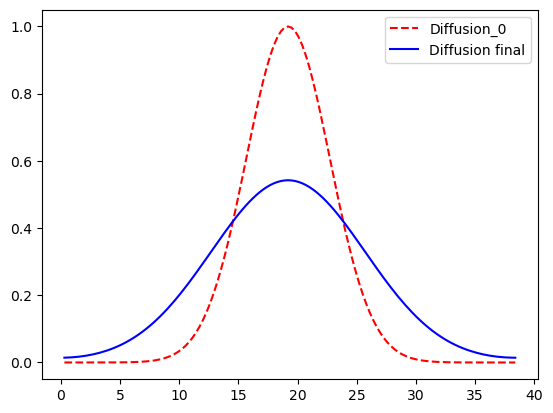

In [14]:
import numpy as np
import matplotlib.pyplot as plt
L = 128        # System size
N = 30000       # Total no. of iterations
delt = 0.1     # temporal step size/resolution
delx = 0.3     # spatial step size/resolution
D = 0.005      # Diffusion constant
c = np.zeros(L)
c0 = np.zeros(L)
K = (2 * np.pi / (L * delx)) * np.concatenate((np.arange(0, L//2), np.arange(-L//2, 0)))

x = np.arange(1, L + 1)
c0 = np.exp(-((x - L/2) * delx / 5)**2)
c = c0.copy()
cc = np.fft.fft(c)
cT = np.zeros((L, N))

for i in range(N):
    for p in range(L):
        cc[p] = cc[p] - D * delt * (K[p]**2) * cc[p]
    cT[:, i] = np.real(np.fft.ifft(cc))
# Neumann_par = D * delt / (delx * delx)
import matplotlib.pyplot as plt

x_plot = x * delx
plt.figure()
plt.plot(x_plot, cT[:,0], 'r--', label = 'Diffusion_0')
plt.plot(x_plot, cT[:,-1], 'b' , label = 'Diffusion final')
plt.legend()
plt.show()

#2 spectral advection   

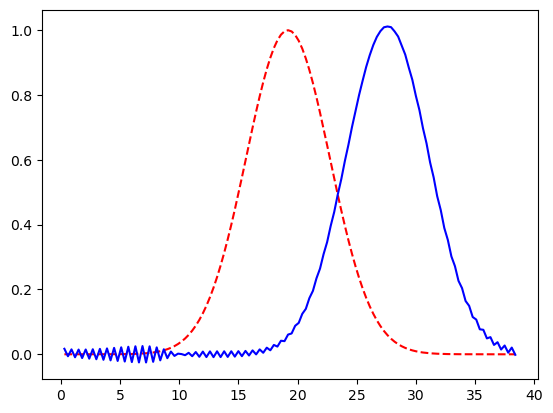

In [19]:
import numpy as np
import matplotlib.pyplot as plt
L = 128        # System size
N = 3000       # Total no. of iterations
delt = 0.01    # temporal step size (smaller than diffusion for stability)
delx = 0.3     # spatial step size
y = np.zeros(L)
y0 = np.zeros(L)
K = (2 * np.pi / (L * delx)) * np.concatenate((
    np.arange(0, L//2),
    np.arange(-L//2, 0)
))
x = np.arange(1, L + 1)
y0 = np.exp(-((x - L/2) * delx / 5)**2)
y = y0.copy()
yy = np.fft.fft(y)
yT = np.zeros((L, N))

for i in range(N):
    for p in range(L):
        yy[p] = yy[p] + delt * (1j * K[p]) * yy[p]
    # Vectorized version:
    # yy = yy + delt * (1j * K) * yy

    yT[:, i] = np.real(np.fft.ifft(yy))


x_plot = x * delx
plt.figure()
plt.plot(x_plot, yT[:,0],'r--', label = "Adv_0")
plt.plot(x_plot, yT[:,-1],'b', label = "Adv_final")
plt.show()

#3     Fockker-Planck

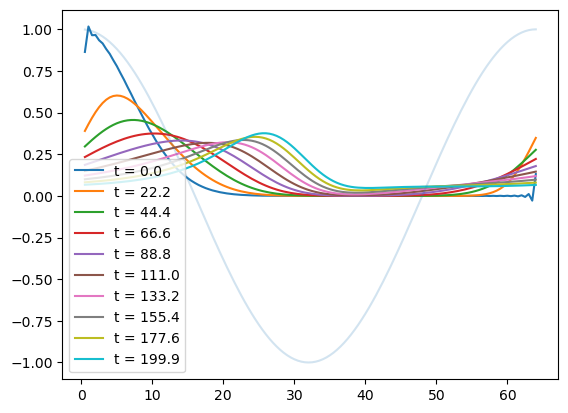

In [36]:
import numpy as np
import matplotlib.pyplot as plt

L, N, D, delt, delx =  128, 2000, 0.2, 0.1, 0.5

x = np.arange(1,L+1)

c0 = np.exp((- ((x)*delx)**2)/100)
c = c0.copy()
cc = np.fft.fft(c)

U = - np.cos(2*np.pi / L*(x-L/2))
Up =(2*np.pi / (L*delx)) * np.sin(2*np.pi / L * (x-L/2))

K = (2*np.pi / (L*delx))* np.concatenate((np.arange(0,L//2),np.arange(-L//2, 0)))

cT = np.zeros((L,N))

for i in range(N):
    rho   = Up*c
    crho = np.fft.fft(rho)

    cc=cc+delt*(-D*(K**2)*cc+1j*K*crho)
    c = np.real(np.fft.ifft(cc))
    cT[:,i]=c

x_plot = x*delx

plt.figure()
idx = np.linspace(0,N-1, 10, dtype= int)

for i in idx:
    plt.plot(x_plot, cT[:, i], label=f"t = {i*delt:.1f}")

plt.plot(x_plot, U, alpha = 0.2)

plt.legend()
plt.show()


[1.0, 1.411382301150188, 1.7181385275931624, 1.998999749874922, 2.246775467197379, 2.5099800796022267, 2.6817904466978773, 2.8460498941515415, 3.041052449399714, 3.1559467676119, 3.344248794572557, 3.5451375149632773, 3.7255872020394314, 3.8397916610149565, 3.928358435784596, 4.033360881448622, 4.178995094517341, 4.328510136294011, 4.4326064567024215, 4.5899891067408864, 4.686149805543993, 4.808326112068523, 4.921788292887048, 5.03626845988178, 5.0990195135927845, 5.213827768540115, 5.360596981680305, 5.491812087098392, 5.569201019895044, 5.687530219699935, 5.79931030382062, 5.89406481131655, 5.989323834958333, 6.1315577139907935, 6.212889826803626, 6.289674077406556, 6.351062903168256, 6.390931074577475, 6.468384651518491, 6.565668282817827, 6.656725921952924, 6.698955142408405, 6.769342656417978, 6.800882295702523, 6.877790342835407, 6.954135460285484, 6.985127056825809, 7.065974808899336, 7.148706176644834, 7.155138014042776, 7.29657453878188, 7.366681749607485, 7.444729679444379, 7

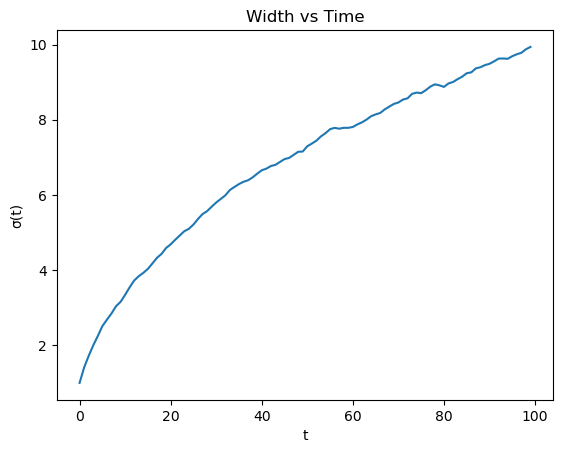

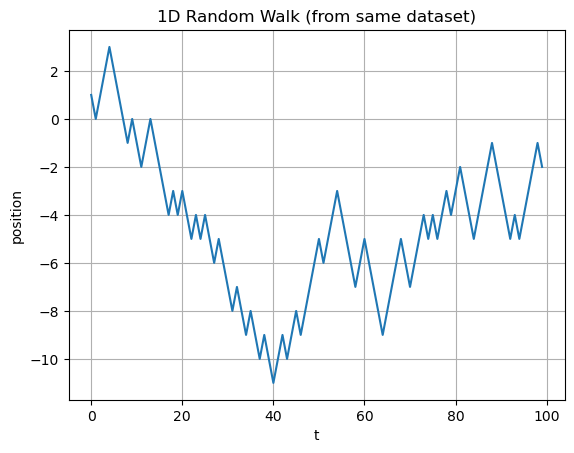

In [71]:
import numpy as np
import matplotlib.pyplot as plt
n=100
l=1000
L=np.zeros(l)
L_t=[]
for j in range(n):
    for i in range(l):
        r=np.random.random()
        if r<=0.5:
            L[i]+=1
        else:
            L[i]-=1
    L_t.append(L.copy())
def sigma(L_snapshot):
    rho={}
    for pos in L_snapshot:
        rho[pos]=rho.get(pos,0)+1
    total=len(L_snapshot)
    sigma2=0
    for x,count in rho.items():
        sigma2+=x**2*(count/total)
    return sigma2**0.5
sigma_t=[]
for i in range(n):
    sigma_t.append(sigma(L_t[i]))
print(sigma_t)
plt.plot(range(n),sigma_t)
plt.xlabel('t')
plt.ylabel('σ(t)')
plt.title('Width vs Time')
# plt.show()
walk_1d = [snapshot[0] for snapshot in L_t]

plt.figure()

# 1D random walk trajectory
plt.plot(range(n), walk_1d)

plt.xlabel("t")
plt.ylabel("position")
plt.title("1D Random Walk (from same dataset)")
plt.grid()

plt.show()


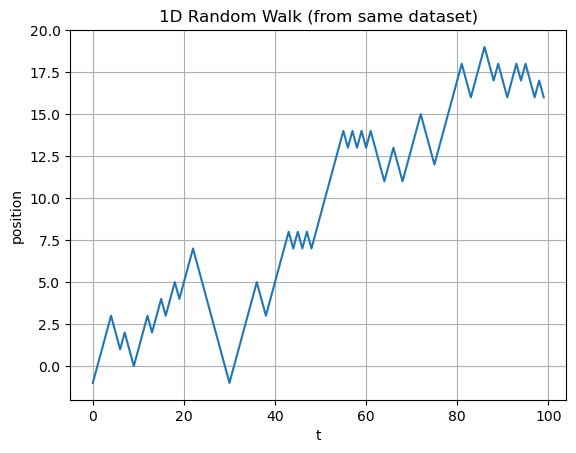

In [40]:
walk_1d = [snapshot[0] for snapshot in L_t]

plt.figure()

# 1D random walk trajectory
plt.plot(range(n), walk_1d)

plt.xlabel("t")
plt.ylabel("position")
plt.title("1D Random Walk (from same dataset)")
plt.grid()

plt.show()